In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [93]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [94]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [95]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [96]:
def chi_sq(theta, uncertainty_multiplier = 1):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/(df['E_COIN_RATE'] * uncertainty_multiplier)**2) / len(df - len(theta))

In [97]:
p0 = [0, 750, 750]
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)

7.8429111520224675


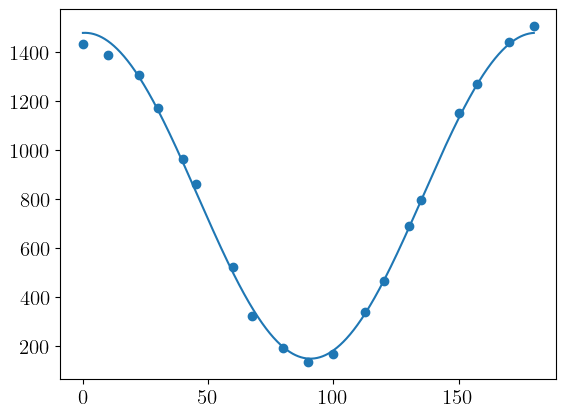

In [98]:
plt.scatter(df["ANGLE"], df["COIN_RATE"])
x = np.linspace(0, 180, 1000)
plt.plot(x, model(x, *pcurve_fit))
print(chi_sq(pcurve_fit))

In [99]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE']**2)

In [100]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [101]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 10000, progress=True)

100%|██████████| 10000/10000 [00:49<00:00, 203.83it/s]


State([[ -1.45499569 673.29764655 811.34356068]
 [ -1.39735078 669.98694561 810.42800717]
 [ -1.50313487 671.10098608 810.36139593]
 [ -1.49755396 674.51774628 812.21052548]
 [ -1.71164214 675.1265151  813.88947571]
 [ -1.4933392  675.91364888 813.83355538]
 [ -1.45349926 673.22471894 812.00900903]
 [ -1.35487502 675.07972774 812.93578408]
 [ -1.25902437 674.48737049 811.70424124]
 [ -1.33642586 674.74882554 813.98523399]
 [ -1.44071637 675.23728009 813.99247336]
 [ -1.59843348 672.09544094 810.48633472]
 [ -1.58153377 671.41199605 812.1000969 ]
 [ -1.36791864 673.83410957 811.55020388]
 [ -1.57173113 673.40309432 811.19351425]
 [ -1.77701138 675.01110704 811.3451278 ]], log_prob=[-129.4276769  -132.02133007 -130.73419777 -129.13200723 -130.35261975
 -129.48502184 -129.19873906 -129.47756165 -130.49538939 -130.02312863
 -129.50763936 -130.39834842 -130.70238642 -129.62675909 -129.64975705
 -131.86400479], blobs=None, random_state=('MT19937', array([4024464938,  649779733, 2865945346, 2

In [102]:
#names of parameters
param_labels = [
    "Phase",
    "Amplitude",
    "Baseline"
]

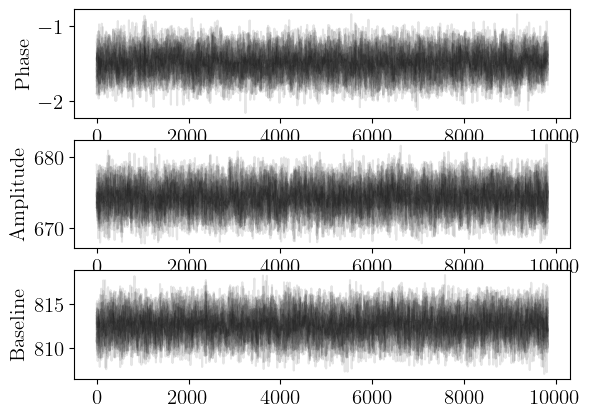

In [103]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

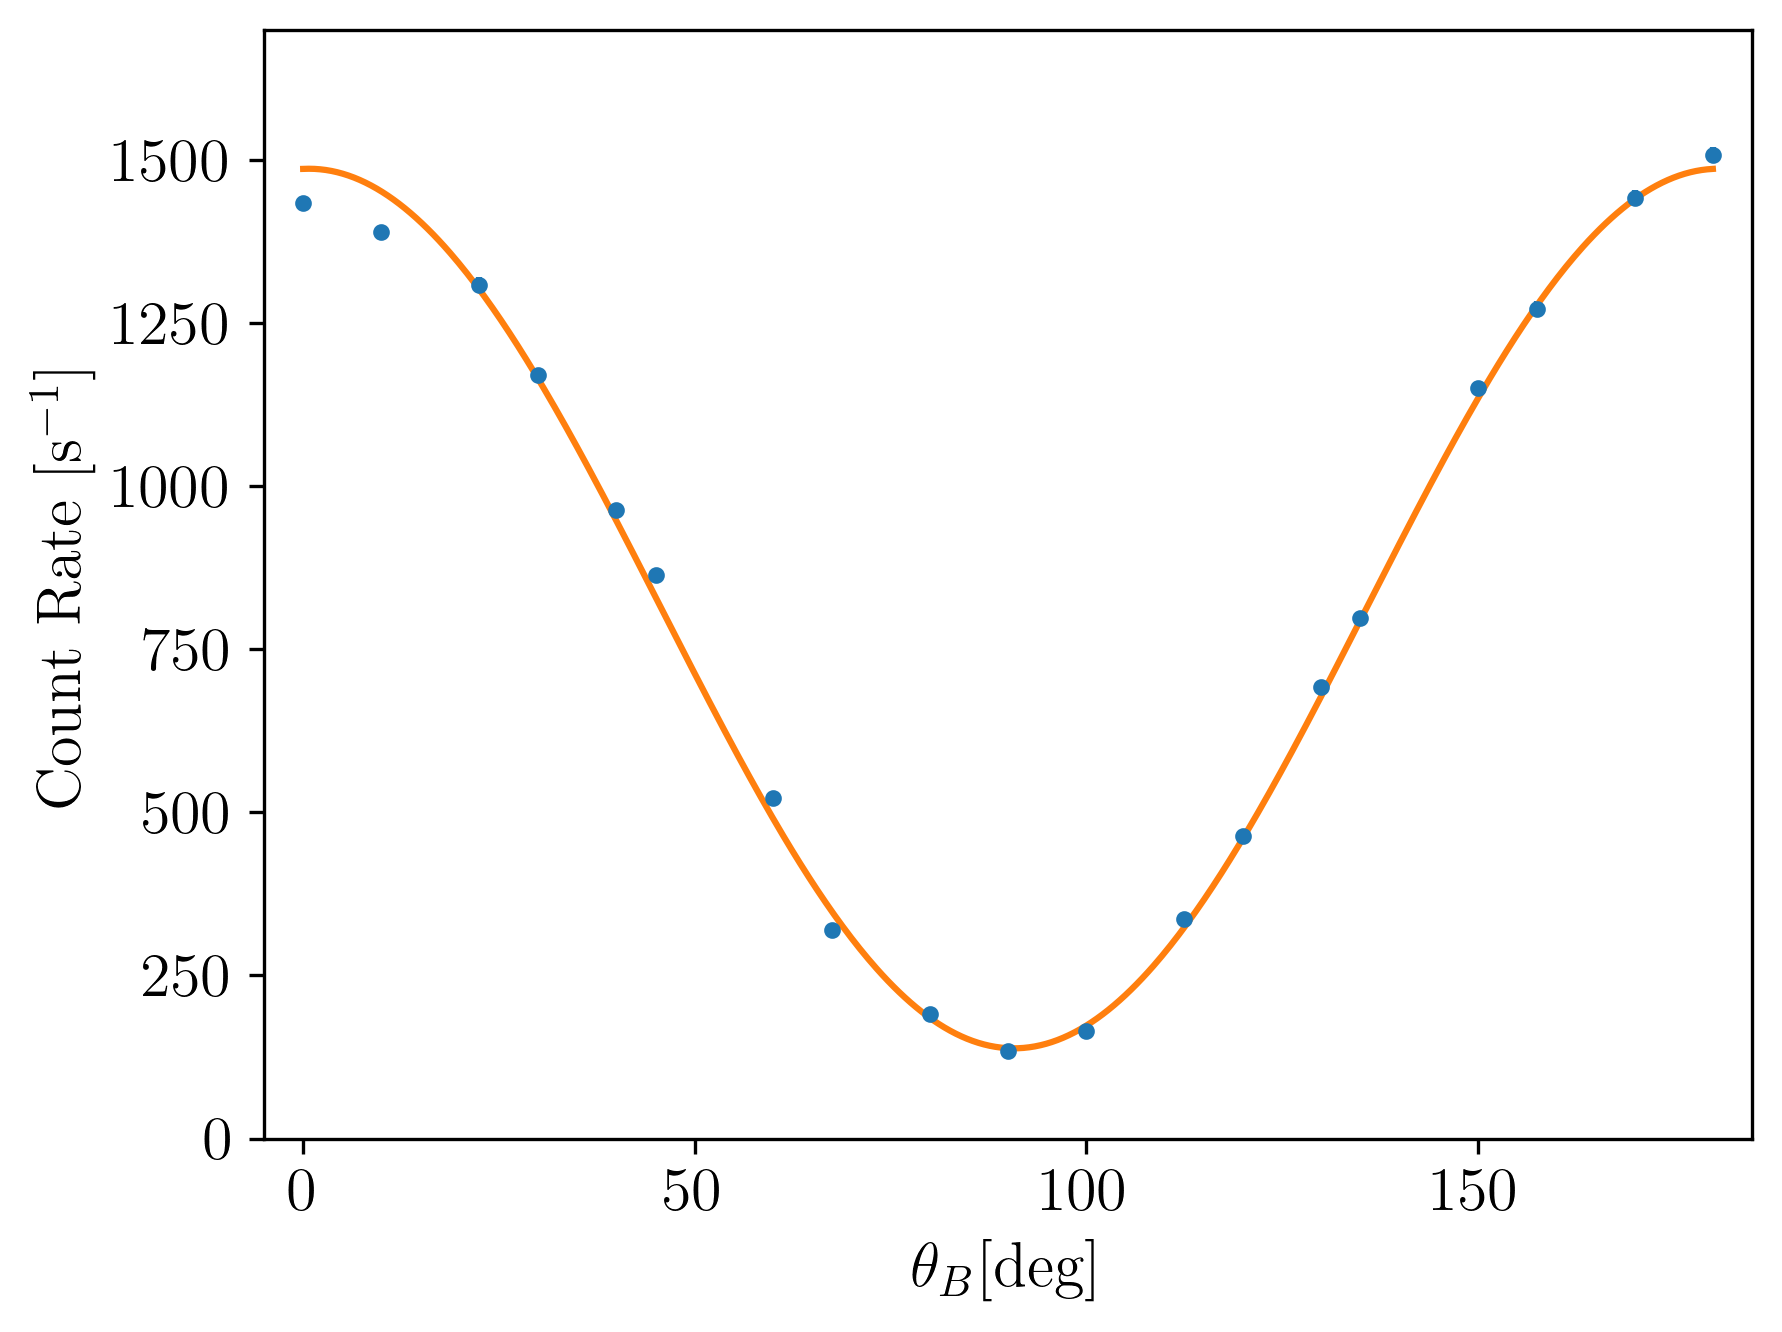

In [104]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"], ls="", marker=".")
x = np.linspace(0, 180, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)

ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit.png", bbox_inches = "tight")

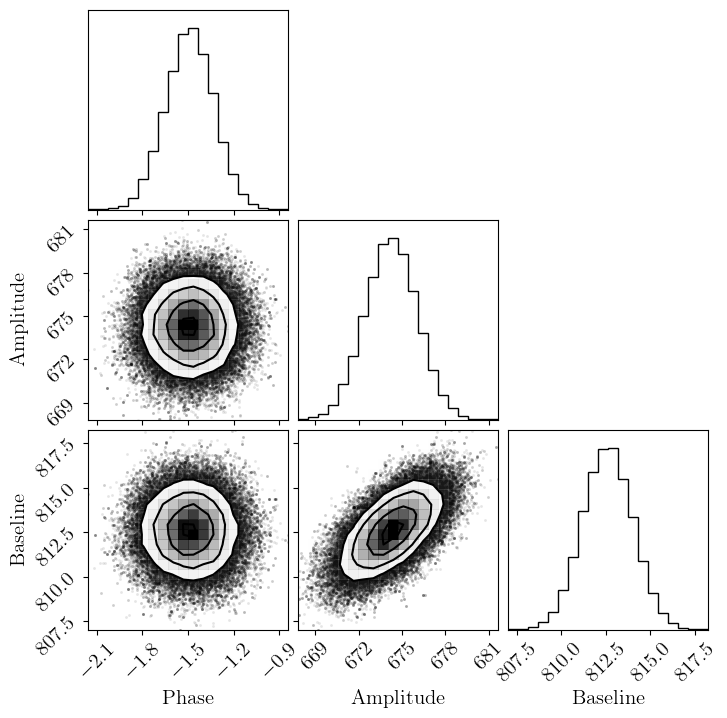

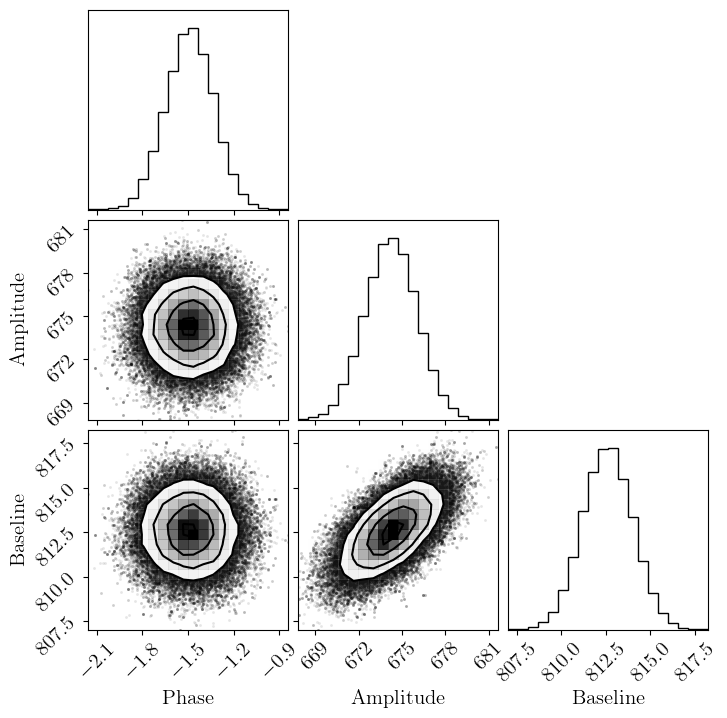

In [105]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels)

In [106]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [107]:

results.to_csv("mcmc_fit.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.486215,0.157570,0.315140,-0.212042
Amplitude,674.274721,1.788459,3.576918,0.005305
Baseline,812.612672,1.409689,2.819378,0.003470


In [108]:
chi_sq_mcmc = chi_sq(np.median(chain, axis = 0))
chi_sq_mcmc
#quite high, will try rescaling errors 

np.float64(6.7895013760816525)

In [109]:
#mcmc log likelihood
def log_prob_adjusted(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/(df['E_COIN_RATE'] * np.sqrt(chi_sq_mcmc))**2)

In [110]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [111]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob_adjusted)
sampler.run_mcmc(x0, 10000, progress=True)

100%|██████████| 10000/10000 [00:50<00:00, 196.28it/s]


State([[ -1.56093397 674.63327807 815.46869388]
 [ -2.038978   670.58243966 808.66401087]
 [ -1.72593696 672.79730701 814.43839781]
 [ -1.83091316 672.08662127 814.09381468]
 [ -1.2453091  678.75440464 818.92618198]
 [ -1.17888134 673.53464108 815.09797815]
 [ -0.9569309  671.22800269 812.40346614]
 [ -2.13514491 672.7942611  811.93145373]
 [ -1.27390785 675.04882513 811.98412324]
 [ -1.51291346 678.73944023 814.61838439]
 [ -1.86925894 673.92341287 806.70271506]
 [ -2.10620525 672.47208577 815.10134197]
 [ -2.09559076 666.92457858 812.6433246 ]
 [ -1.53372128 667.53598513 810.75578245]
 [ -1.28014535 678.94644547 815.49216915]
 [ -1.78854564 674.24394726 818.0492709 ]], log_prob=[-19.42711476 -20.44707214 -19.57611301 -19.80820952 -20.61331909
 -19.7833905  -20.16793866 -20.25597388 -19.2130268  -19.46564395
 -21.39112557 -20.81333302 -22.01864463 -20.15929719 -19.64578777
 -20.96627837], blobs=None, random_state=('MT19937', array([1350393296, 3651840016, 2152734471,  793353699, 31777

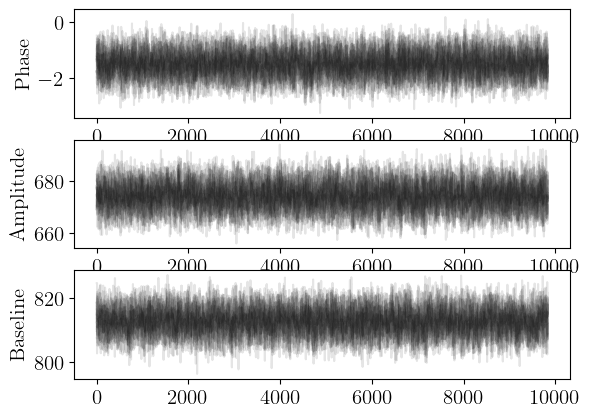

In [112]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

1.0000256658515583


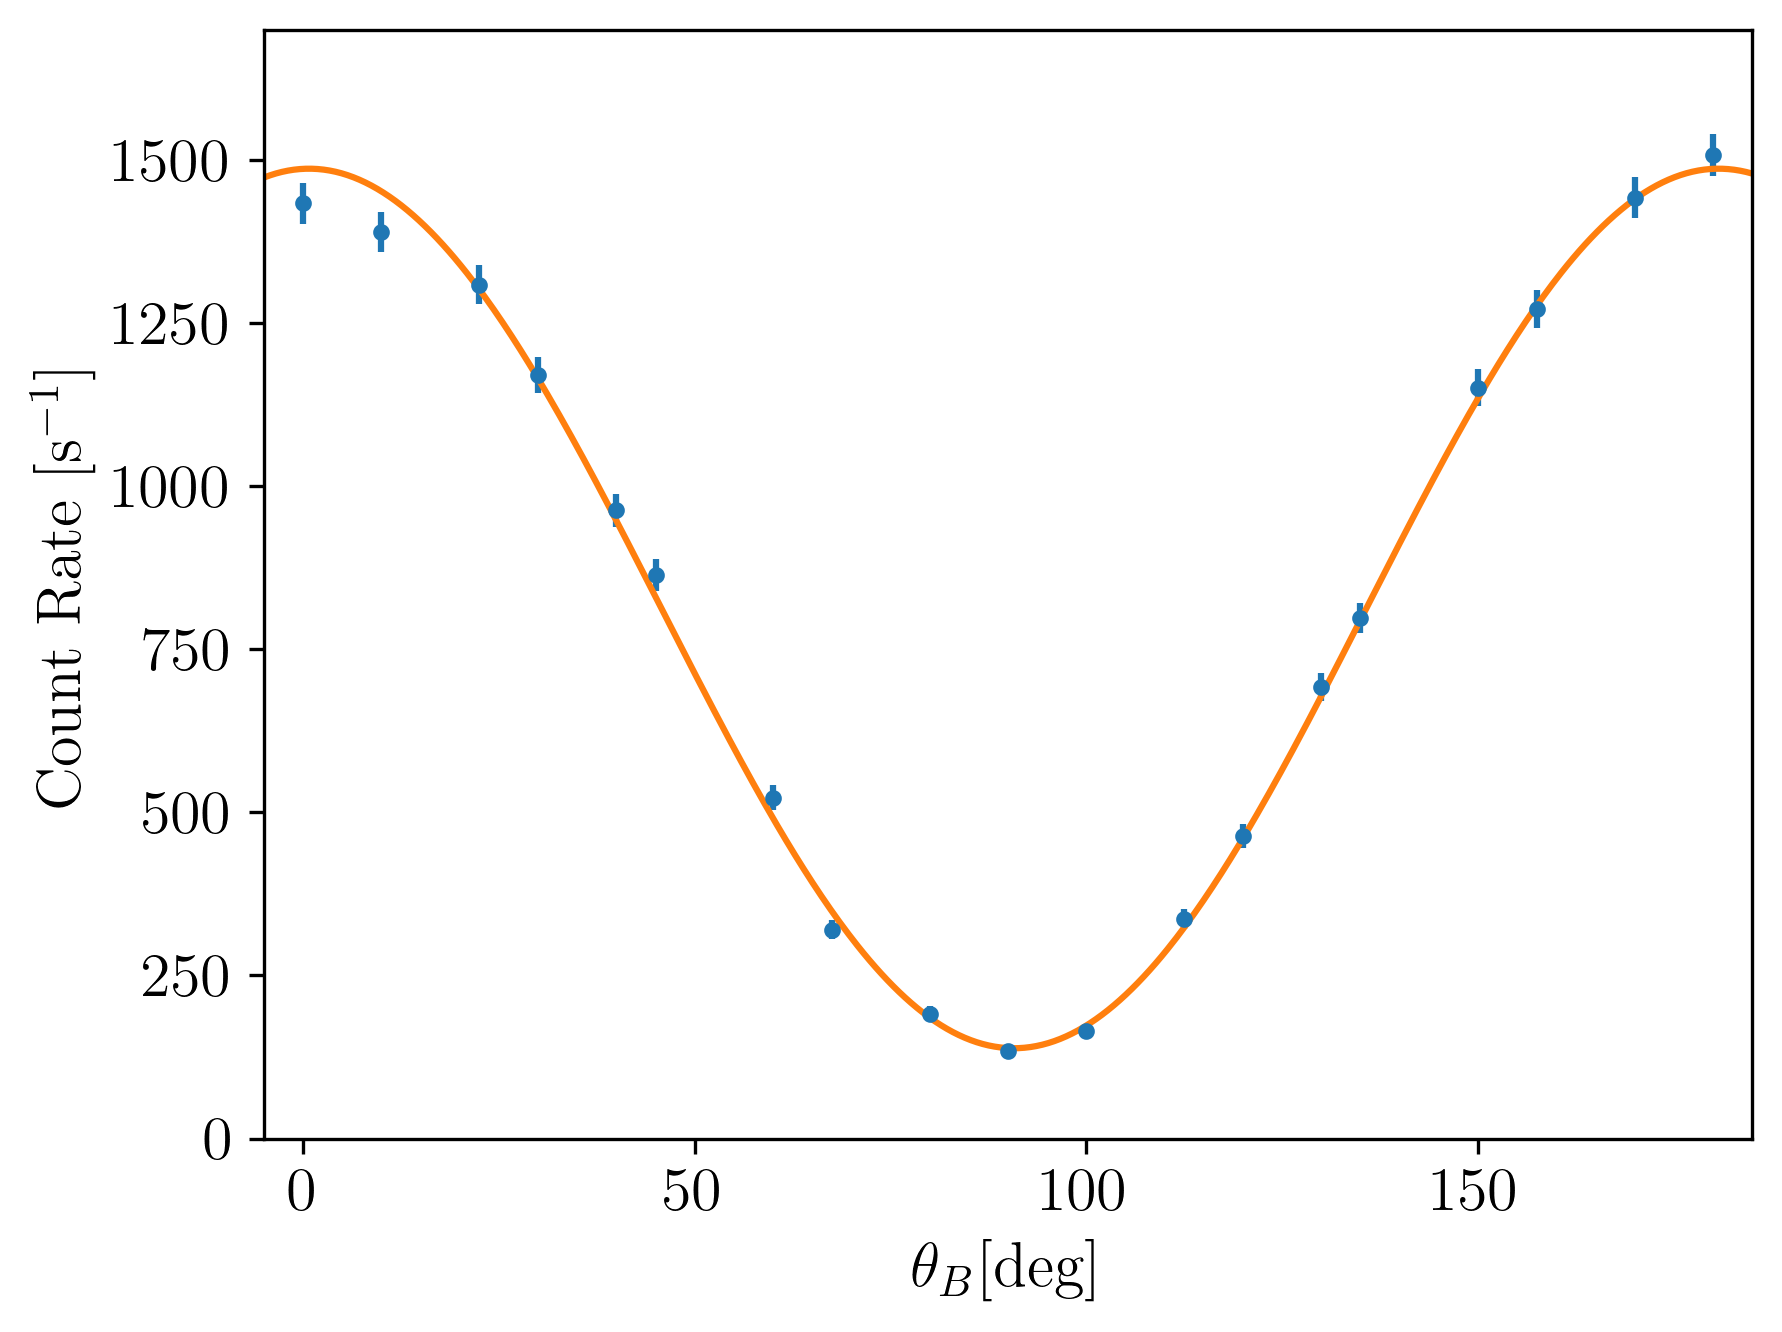

In [113]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit_adjusted_sigma.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

In [114]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [115]:
results.to_csv("mcmc_fit_adjusted.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.497916,0.406991,0.813982,-0.543409
Amplitude,674.252396,4.651664,9.303328,0.013798
Baseline,812.723106,3.717995,7.435990,0.009149


1.0000256658515583


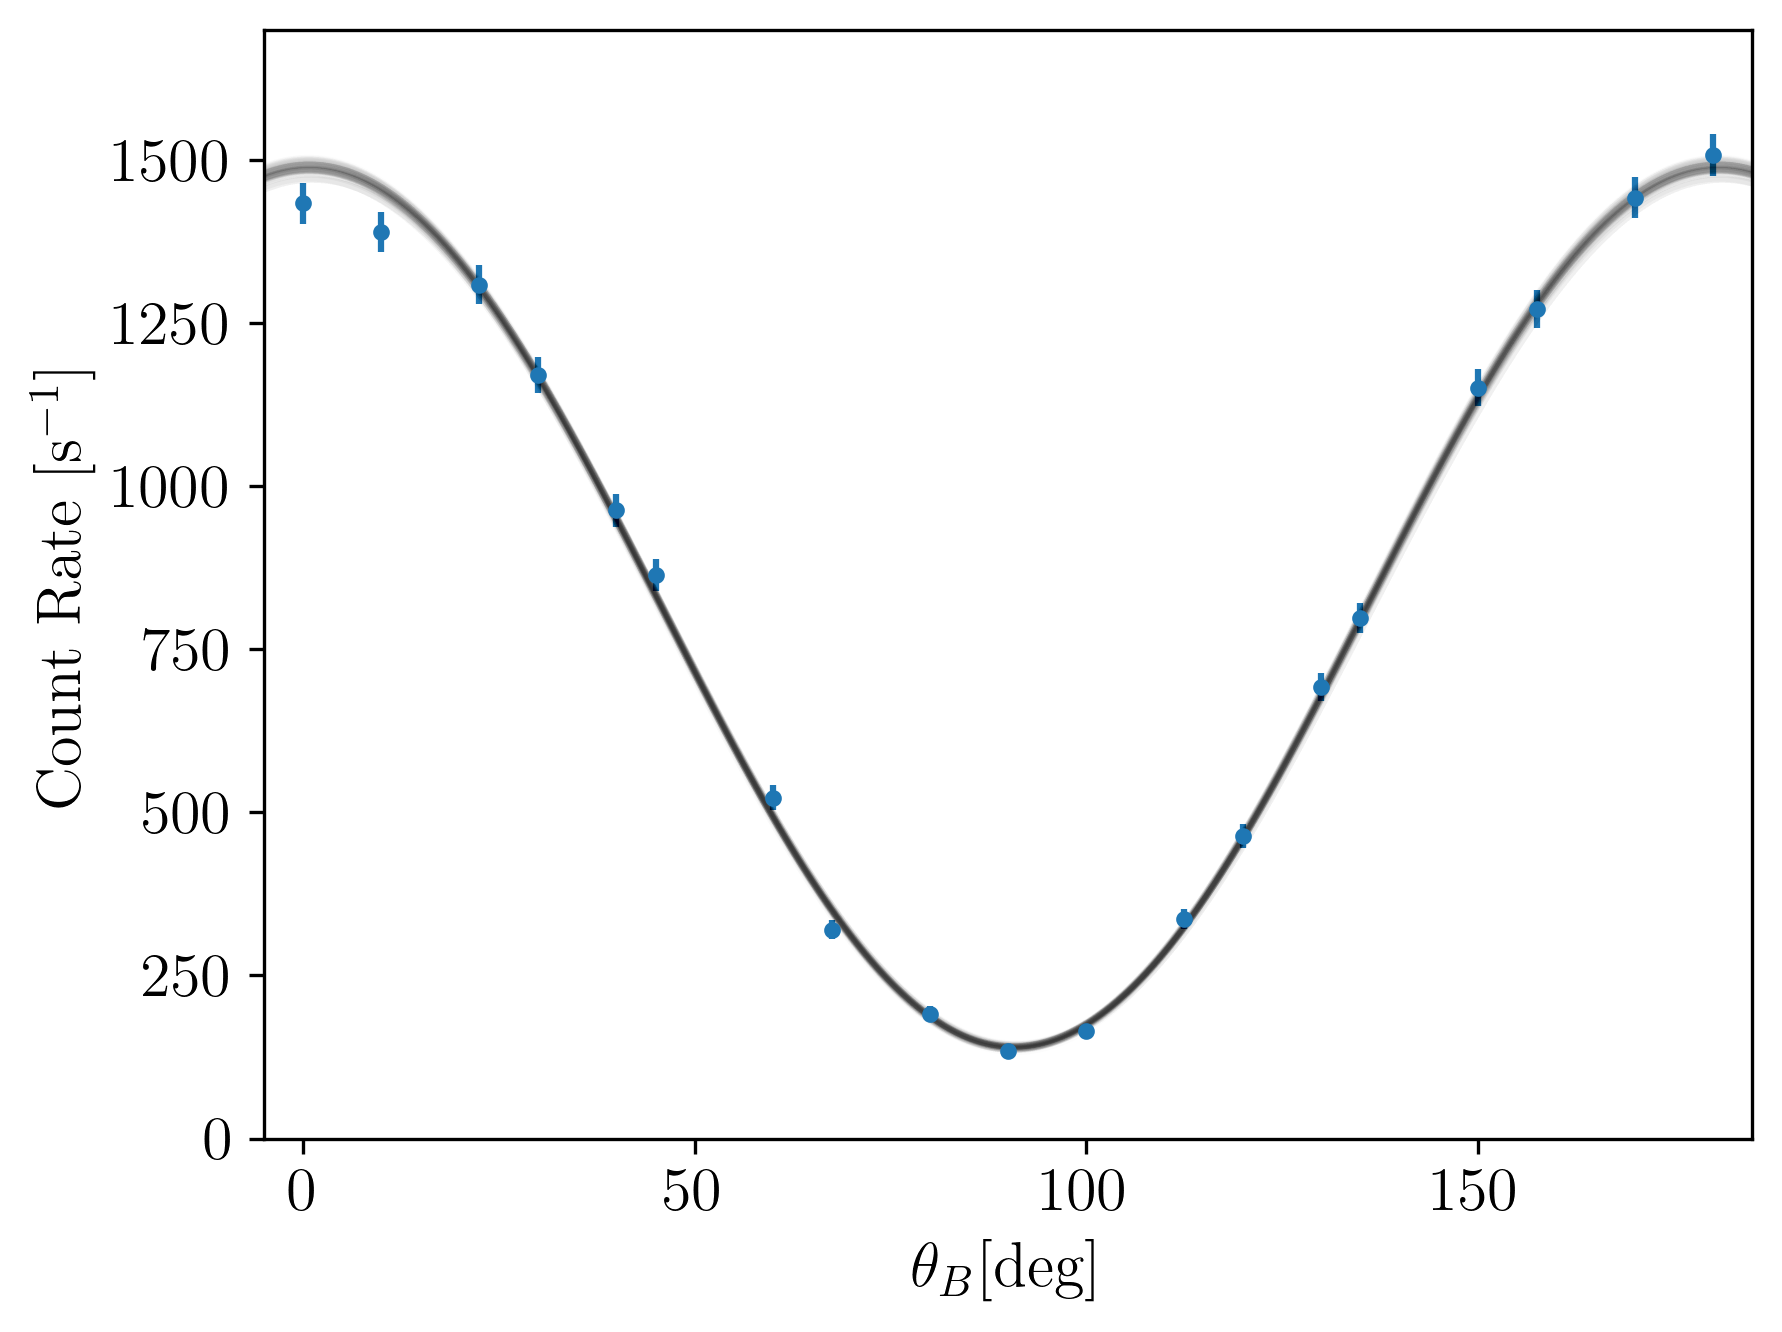

In [116]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
#ax.plot(x, model(x, *np.median(chain, axis = 0)))
for i in range(100):
    ax.plot(x, model(x, *chain[-i]), color = "black", alpha = 0.01)
ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/density_plot.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

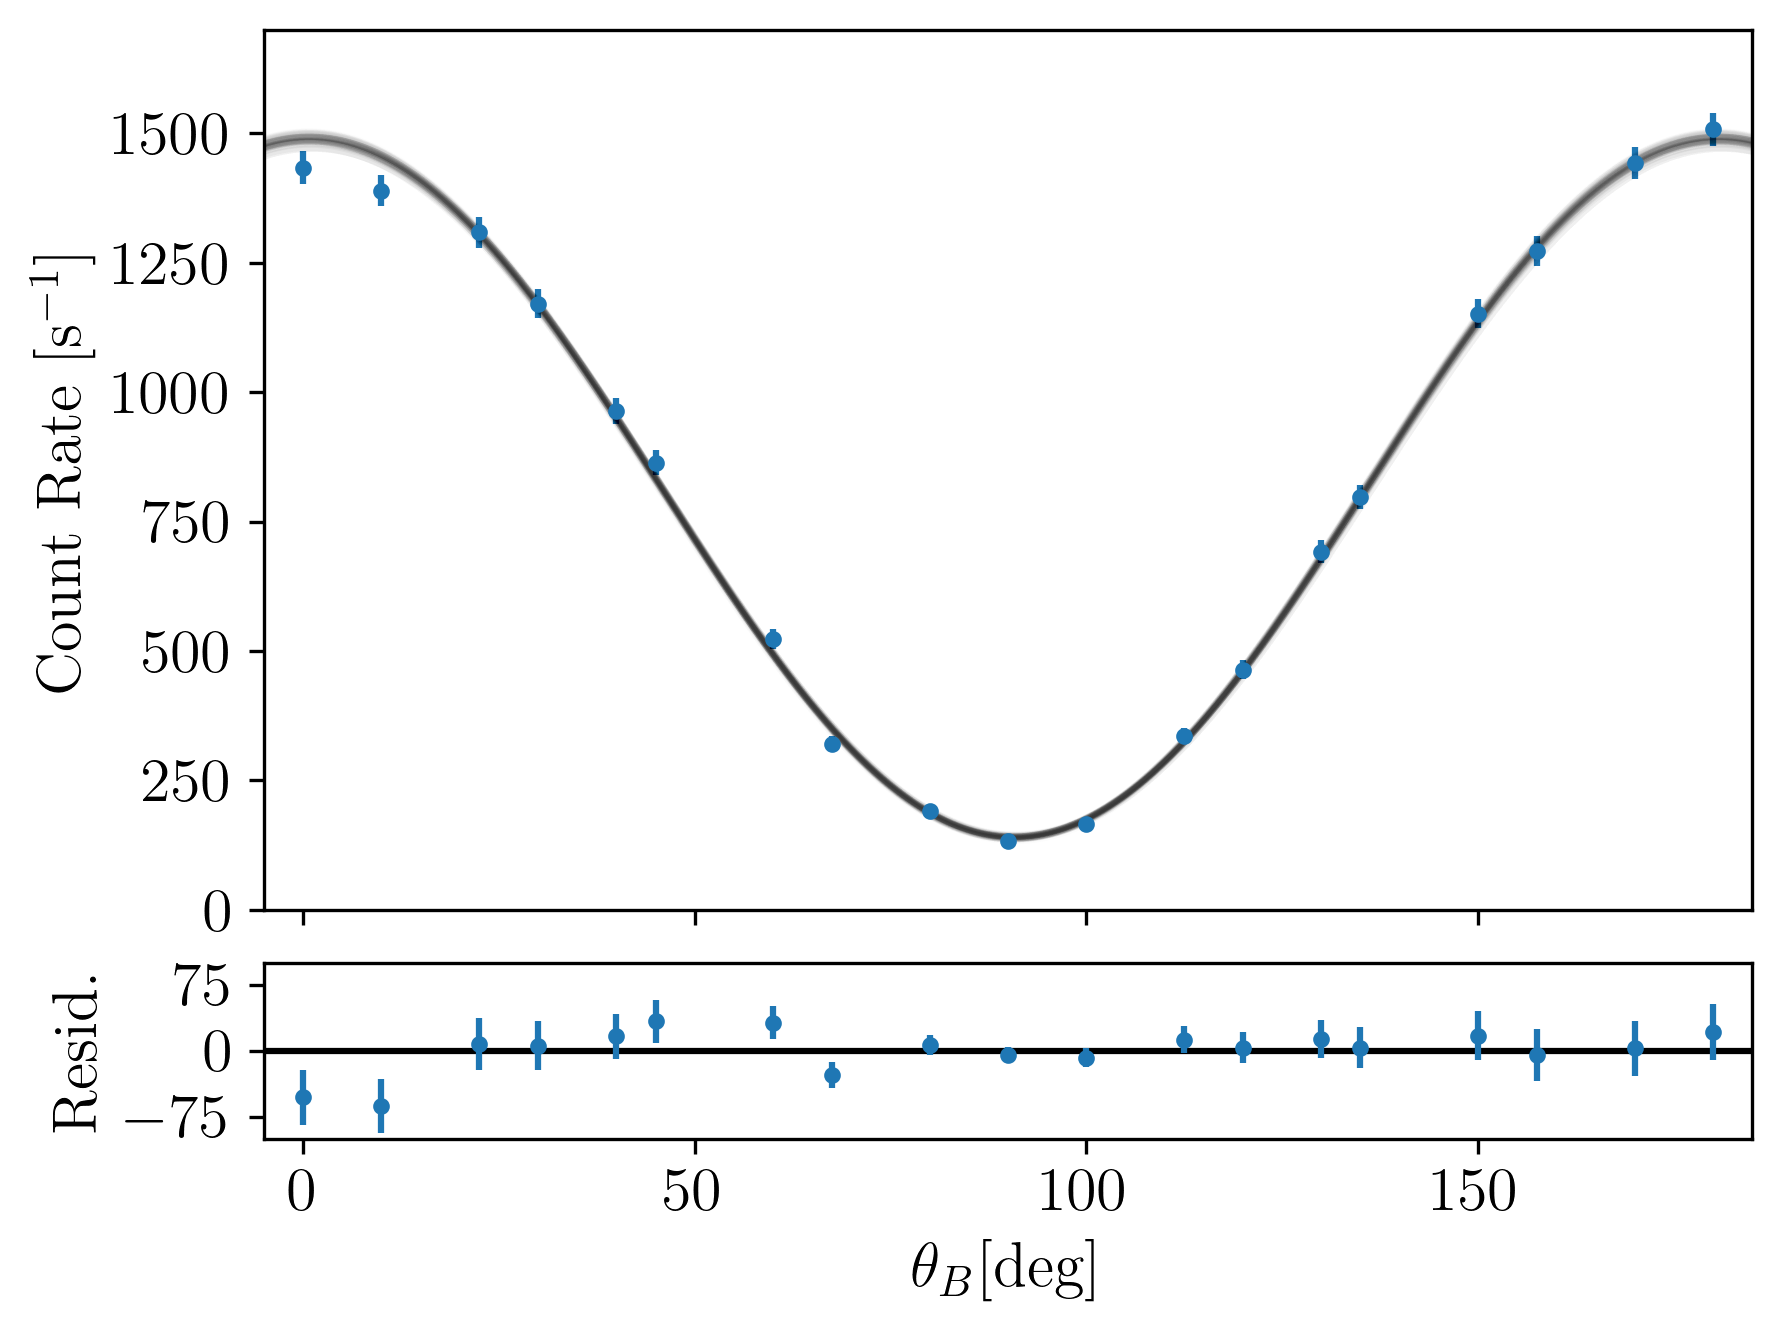

In [117]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, axs = plt.subplots(2, dpi = 300, height_ratios = [5, 1], sharex = True)

axs[0].errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
#ax.plot(x, model(x, *np.median(chain, axis = 0)))
for i in range(100):
    axs[0].plot(x, model(x, *chain[-i]), color = "black", alpha = 0.01)
axs[0].set_ylim(0, 1700)
axs[0].set_xlim(-5, 185)
axs[1].set_xlabel("$\\theta_B [\\text{deg}]$")
axs[0].set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.subplots_adjust(hspace=.1)

axs[1].set_ylabel("Resid.")
axs[1].set_yticks([-75, 0, 75])
axs[1].set_ylim([-100,100])
axs[1].axhline(0, color = "black")
axs[1].errorbar(df['ANGLE'], df['COIN_RATE'] - model(df["ANGLE"], *np.median(chain, axis = 0)), df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
plt.savefig("figures/residual_plot.png", bbox_inches = "tight")